In [ ]:
#pip install kagglehub pandas numpy matplotlib seaborn

In [54]:
import kagglehub
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
path = kagglehub.dataset_download("harlfoxem/housesalesprediction", force_download=True)
print(os.listdir(path))

In [19]:
actual_path = str(path) + "\\" + os.listdir(path)[0]

In [20]:
shutil.copy(actual_path, "data/")

'data/kc_house_data.csv'

In [74]:
df = pd.read_csv("data/kc_house_data.csv")

In [75]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [77]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

df['renovated'] = (df['yr_renovated'] != 0).astype(int)
df['yr_renovated'] = df['yr_renovated'].replace(0, np.nan)

df['basement'] = (df['sqft_basement'] != 0).astype(int)
df = df.drop(columns=['sqft_basement'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df.drop(columns=['date'])

<Axes: >

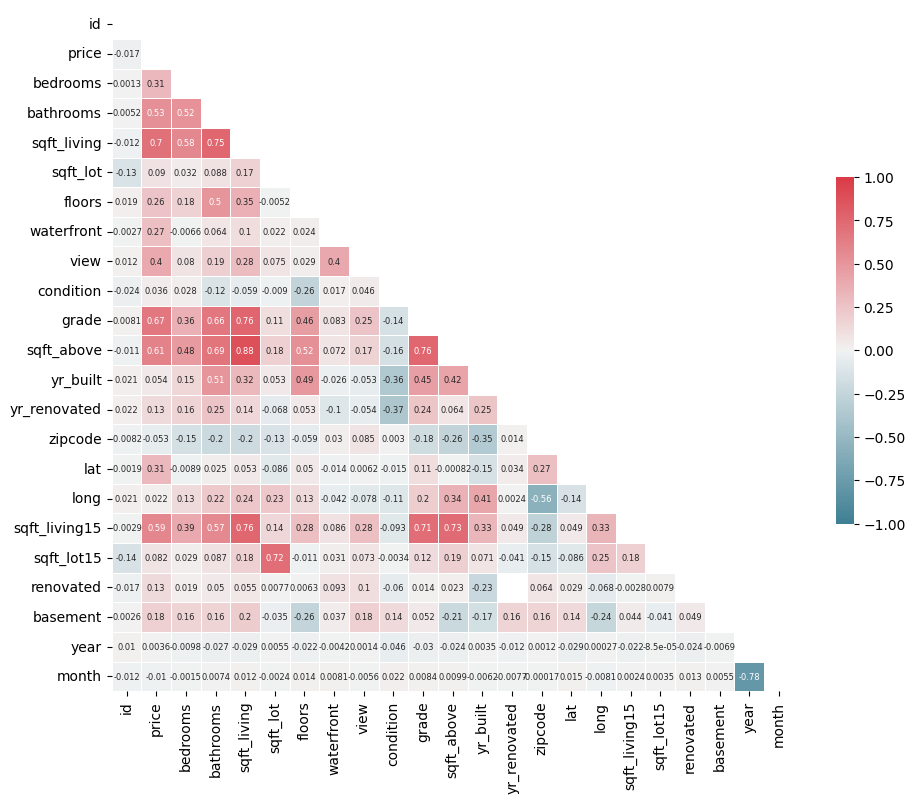

In [78]:
f, ax = plt.subplots(figsize=(11,9))
corr = df.corr(numeric_only=True)  
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, annot_kws={"size": 6})

In [79]:
df.drop(['id', 'year', 'month', 'sqft_above', 
         'sqft_living15', 'sqft_lot15', 'zipcode'], axis=1, inplace=True)

<Axes: >

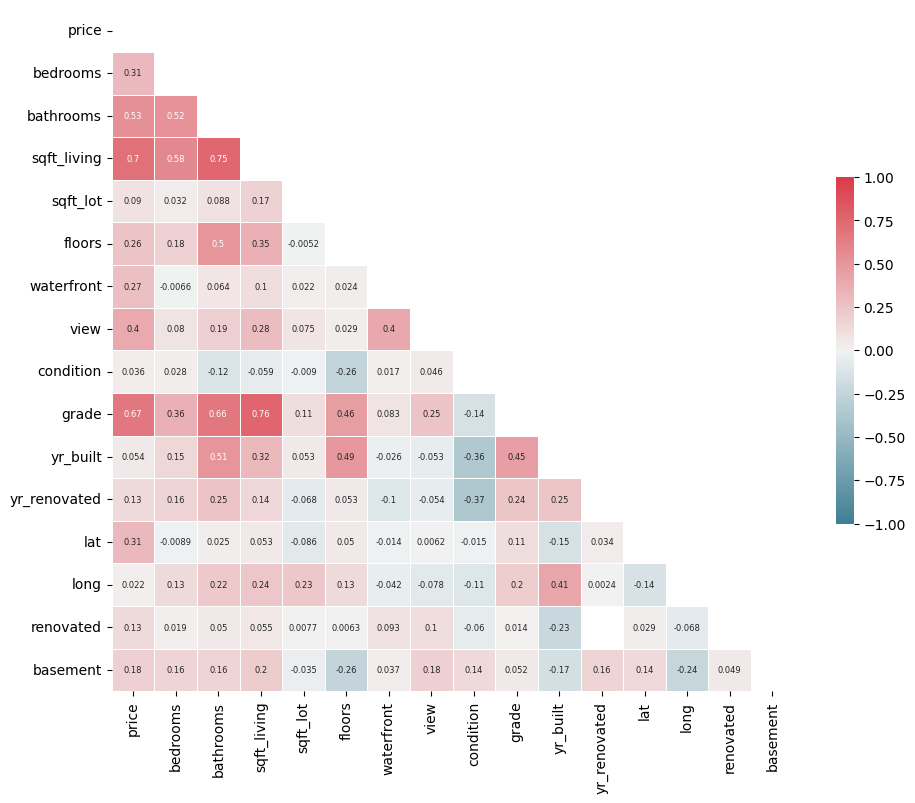

In [80]:
f, ax = plt.subplots(figsize=(11,9))
corr_1 = df.corr(numeric_only=True)  
mask = np.triu(np.ones_like(corr_1, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_1, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, annot_kws={"size": 6})